# Module 3a - Calculate yield and water productivity in irrigated systems

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wateraccounting/WaPORIPA/blob/main/Notebooks_v1.0/Module_3a_Yield_WP.ipynb)


This notebook calculates from seasonal WaPOR AETI, T and NPP data the following indicators on cropped land:

* Step 0 - Set up: import modules/libraries, load data, and define output folders
* Step 1 - Calculate land and water productivity:
  * Total biomass production
  * Yield*
  * Biomass water productivity
  * Crop water productivity*

*requires crop type information

#### References:
* Chukalla, A. D., Mul, M. L., van der Zaag, P., van Halsema, G., Mubaya, E., Muchanga, E., den Besten, N., and Karimi, P.: [A framework for irrigation performance assessment using WaPOR data: the case of a sugarcane estate in Mozambique](https://doi.org/10.5194/hess-26-2759-2022), Hydrol. Earth Syst. Sci., 26, 2759–2778, 2022.


## **0. Import packages/libraries**

In [1]:
!pip install rasterio --quiet
!pip install rioxarray --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.9 MB/s eta 0:00:00


In [2]:
import os                                 # Provides functions for interacting with the operating system (e.g., file and directory operations)
import sys                                # Access to system-specific parameters and functions, such as command-line arguments
import glob                               # Used to retrieve files/pathnames matching a specified pattern
import re                                 # Regular expression operations (e.g., re.sub() for substring replacement)
import pandas as pd                       # Data manipulation and analysis, particularly for tabular data in DataFrame format
import numpy as np                        # Provides support for large, multi-dimensional arrays and matrices, along with a collection of mathematical functions
import rasterio                           # Handles raster data input/output and geospatial processing
import rioxarray as riox                  # Extends xarray for geospatial raster data processing and interaction with CRS
import xarray as xr                       # For working with multi-dimensional arrays and datasets, often used with NetCDF and climate data
import calendar                           # Functions related to calendar dates, such as formatting and printing dates
import datetime                           # Supplies classes for manipulating dates and times
from osgeo import gdal                    # Geospatial Data Abstraction Library, used for reading/writing raster and vector geospatial data formats
import matplotlib.pyplot as plt           # Used for creating static, animated, and interactive visualizations (e.g., 2D plots, bar charts)
from IPython.display import display, HTML

## **1. Upload data**

### A. Upload and unzip files containing seasonal AETI, seasonal T and seasonal NPP

In [3]:
# Upload Zip file containing seasonal data (AETI, T, NPP). i.e., WaPORv3_seasonal output of **Module_1a** or **Module_1b**
from google.colab import files
uploaded = files.upload()          # Opens a file upload dialog to select a zip file from the local system.

Saving pywapor_out.zip to pywapor_out.zip


In [ ]:
# # From google drive     - output of **Module_1a** or **Module_1b**
# from google.colab import drive
# drive.mount('/content/drive')

### Unzip the seasonal AETI, T, and NPP files to the temporary repository

In [4]:
# 1) Unzipping the seasonal data of **pywapor_out** into their respective directories (AETI, NPP, T).
!unzip '/content/pywapor_out.zip' -d '/content'

Archive:  /content/pywapor_out.zip
   creating: /content/content/output/
   creating: /content/content/output/seasonal/
   creating: /content/content/output/seasonal/pywapor_T_S/
  inflating: /content/content/output/seasonal/pywapor_T_S/pywapor_T_S_2024-05-01_2024-09-30.tif  
   creating: /content/content/output/seasonal/pywapor_I_S/
  inflating: /content/content/output/seasonal/pywapor_I_S/pywapor_I_S_2024-05-01_2024-09-30.tif  
   creating: /content/content/output/seasonal/pywapor_AETI_S/
  inflating: /content/content/output/seasonal/pywapor_AETI_S/pywapor_AETI_S_2024-05-01_2024-09-30.tif  
   creating: /content/content/output/seasonal/pywapor_NPP_S/
  inflating: /content/content/output/seasonal/pywapor_NPP_S/pywapor_NPP_S_2024-05-01_2024-09-30.tif  
   creating: /content/content/output/seasonal/pywapor_E_S/
  inflating: /content/content/output/seasonal/pywapor_E_S/pywapor_E_S_2024-05-01_2024-09-30.tif  
   creating: /content/content/output/seasonal/pywapor_RSM_S/
  inflating: /conte

In [ ]:
# # 2) Unzipping the seasonal data of **WaPORv3_seasonal** into their respective directories (AETI, NPP, T).
# !unzip '/content/WaPORv3_seasonal.zip' -d '/content'

### Import seasonal AETI, T, and NPP data: Set up paths to access the unzipped data

In [5]:
# 1) Set up paths to access the unzipped **pywapor_out** seasonal AETI, T, and NPP data.
dir_proj = os.path.split(os.getcwd())[0]            # Get the current project directory.
dir_data = r"/content/content/output/seasonal/"     # Define the base directory where the data is stored.

# Define paths to the seasonal directories, and retrieve all TIFF files from the respective folders using glob.
input_folderAETI  = os.path.join(dir_proj, dir_data, "pywapor_AETI_S")
AETI_fhs = glob.glob(os.path.join(input_folderAETI, '*.tif'))

input_folderT  = os.path.join(dir_proj, dir_data, "pywapor_T_S")
T_fhs = glob.glob(os.path.join(input_folderT, '*.tif'))

input_folderNPP  = os.path.join(dir_proj, dir_data, "pywapor_NPP_S")
NPP_fhs = glob.glob(os.path.join(input_folderNPP, '*.tif'))

# Output: Lists of file paths for AETI, T, and NPP data.
AETI_fhs, T_fhs, NPP_fhs

(['/content/content/output/seasonal/pywapor_AETI_S/pywapor_AETI_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/seasonal/pywapor_T_S/pywapor_T_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/seasonal/pywapor_NPP_S/pywapor_NPP_S_2024-05-01_2024-09-30.tif'])

In [ ]:
# # 2) Set up paths to access the unzipped WaPORv3_seasonal's seasonal AETI, T, and NPP data.
# dir_proj = os.path.split(os.getcwd())[0]            # Get the current project directory.
# dir_data = r"/content/content/output/"     # Define the base directory where the data is stored.

# # Define paths to the seasonal directories, and retrieve all TIFF files from the respective folders using glob.
# input_folderAETI  = os.path.join(dir_proj, dir_data, "AETI_season")
# AETI_fhs = glob.glob(os.path.join(input_folderAETI, '*.tif'))

# input_folderT  = os.path.join(dir_proj, dir_data, "T_season")
# T_fhs = glob.glob(os.path.join(input_folderT, '*.tif'))

# input_folderNPP  = os.path.join(dir_proj, dir_data, "NPP_season")
# NPP_fhs = glob.glob(os.path.join(input_folderNPP, '*.tif'))

# # Output: Lists of file paths for AETI, T, and NPP data.
# AETI_fhs, T_fhs, NPP_fhs

(['/content/content/output/AETI_season/AETI_season1_2022-11-01_to_2023-06-01.tif'],
 ['/content/content/output/T_season/T_season1_2022-11-01_to_2023-06-01.tif'],
 ['/content/content/output/NPP_season/NPP_season1_2022-11-01_to_2023-06-01.tif'])

### B. Upload and unzip the files containing seasonal ETc - output of Module_2 (CWRGreenBlueETa)

In [6]:
# Upload Zip file containing seasonal data ETc. i.e., output of **Module_2**
from google.colab import files
uploaded = files.upload()          # Opens a file upload dialog to select a zip file from the local system.

Saving CWRGreenBlueETa.zip to CWRGreenBlueETa.zip


In [ ]:
# # From google drive     - output of **Module_2**
# from google.colab import drive
# drive.mount('/content/drive')

### Unzip the seasonal ETc, Green ETa, Blue ETa, Crop mask

In [7]:
# Unzipping the seasonal data of **Module_2**
!unzip '/content/CWRGreenBlueETa.zip' -d '/content'

Archive:  /content/CWRGreenBlueETa.zip
   creating: /content/content/output/CropMask/
  inflating: /content/content/output/CropMask/GharbiaRice_resampled.tif  
   creating: /content/content/output/2L3_ETc_month/
  inflating: /content/content/output/2L3_ETc_month/ETcmon_2024-06-01_to_2024-06-30.tif  
  inflating: /content/content/output/2L3_ETc_month/ETcmon_2024-05-01_to_2024-05-31.tif  
  inflating: /content/content/output/2L3_ETc_month/ETcmon_2024-08-01_to_2024-08-31.tif  
  inflating: /content/content/output/2L3_ETc_month/ETcmon_2024-09-01_to_2024-09-30.tif  
  inflating: /content/content/output/2L3_ETc_month/ETcmon_2024-07-01_to_2024-07-31.tif  
   creating: /content/content/output/PCPeff_month/
  inflating: /content/content/output/PCPeff_month/PCPeffmon_2024-09-01_to_2024-09-30.tif  
  inflating: /content/content/output/PCPeff_month/PCPeffmon_2024-07-01_to_2024-07-31.tif  
  inflating: /content/content/output/PCPeff_month/PCPeffmon_2024-08-01_to_2024-08-31.tif  
  inflating: /conte

### Import seasonal ETc data, resampled crop mask: Set up paths to access the unzipped data

In [8]:
# Set up paths to access the unzipped seasonal ETp data
dir_proj = os.path.split(os.getcwd())[0]   # Get the current project directory.
dir_data = r"/content/content/output/"     # update directory

# Define paths to the seasonal directory and retrieve all TIFF files from the respective folder using glob.
input_folderETc  = os.path.join(dir_proj, dir_data, "ETc_season")
ETc_fhs          = glob.glob(os.path.join(input_folderETc, '*.tif'))

input_folderMask = os.path.join(dir_proj, dir_data, "CropMask")
CropMask_fhs     = glob.glob(input_folderMask + '/*.tif')

# Output: Lists of file paths for ETc
ETc_fhs, CropMask_fhs

(['/content/content/output/ETc_season/ETc_season1_2024-05-01_to_2024-09-30.tif'],
 ['/content/content/output/CropMask/GharbiaRice_resampled.tif'])

## **2. Mask the raster data using the crop mask**

## Step I. Import the raster data (WaPOR layers and crop mask)

In [9]:
# Define directories
dir_proj = os.path.split(os.getcwd())[0]
dir_data = "/content/content/output/"

# Define paths to the seasonal directories, and retrieve all TIFF files from the respective folders using glob.
input_folderAETI  = os.path.join(dir_proj, dir_data, "seasonal/pywapor_AETI_S") # "AETI_season" if Module_1a, or "seasonal/pywapor_T_S" if Module_1b
AETI_fhs = glob.glob(os.path.join(input_folderAETI, '*.tif'))

input_folderT  = os.path.join(dir_proj, dir_data, "seasonal/pywapor_T_S")
T_fhs = glob.glob(os.path.join(input_folderT, '*.tif'))

input_folderNPP  = os.path.join(dir_proj, dir_data, "seasonal/pywapor_NPP_S")
NPP_fhs = glob.glob(os.path.join(input_folderNPP, '*.tif'))

input_folderETc  = os.path.join(dir_proj, dir_data, "ETc_season")
ETc_fhs          = glob.glob(os.path.join(input_folderETc, '*.tif'))

input_folderMask = os.path.join(dir_proj, dir_data, "CropMask")
input_fhsMask = sorted(glob.glob(input_folderMask + '/*.tif'))


# Output: Lists of file paths for AETI, T, and NPP data.
print ()


# Output folders
output_folders = {
    "AETIs": os.path.join(dir_proj, dir_data, "AETIs_masked"),
    "Ts": os.path.join(dir_proj, dir_data, "Ts_masked"),
    "NPPs": os.path.join(dir_proj, dir_data, "NPPs_masked"),
    "ETcs": os.path.join(dir_proj, dir_data, "ETcs_masked")
}


# Ensure output directories exist
for folder in output_folders.values():
    os.makedirs(folder, exist_ok=True)

# Load Mask (Ensuring shape & CRS match)
mask_file = input_fhsMask[0]  # Assuming only one mask file
with rasterio.open(mask_file) as mask_raster:
    mask = mask_raster.read(1)
    mask = mask == 1  # Convert to boolean (True where mask == 1)
    mask_transform = mask_raster.transform
    mask_crs = mask_raster.crs
    mask_shape = mask_raster.shape

AETI_fhs, T_fhs, NPP_fhs, ETc_fhs, input_fhsMask

(['/content/content/output/seasonal/pywapor_AETI_S/pywapor_AETI_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/seasonal/pywapor_T_S/pywapor_T_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/seasonal/pywapor_NPP_S/pywapor_NPP_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/ETc_season/ETc_season1_2024-05-01_to_2024-09-30.tif'],
 ['/content/content/output/CropMask/GharbiaRice_resampled.tif'])

## Step II. Mask the resampled raster (WaPOR) data

In [10]:
# Function to apply the mask with alignment checks
def apply_mask_and_save(input_files, output_folder):
    for input_file in input_files:
        with rasterio.open(input_file) as src:
            if src.shape != mask_shape:
                print(f"Skipping {input_file} (Shape mismatch: {src.shape} vs {mask_shape})")
                continue
            if src.crs != mask_crs:
                print(f"Skipping {input_file} (CRS mismatch: {src.crs} vs {mask_crs})")
                continue

            data = src.read(1)
            masked_data = np.where(mask, data, np.nan)  # Keep values where mask==1, else NaN

            output_file = os.path.join(output_folder, os.path.basename(input_file))

            with rasterio.open(output_file, 'w', driver='GTiff',
                               height=src.height, width=src.width,
                               count=1, dtype=src.dtypes[0],
                               crs=src.crs, transform=src.transform,
                               nodata=np.nan) as dst:
                dst.write(masked_data, 1)

# Apply masking
apply_mask_and_save(AETI_fhs, output_folders["AETIs"])
apply_mask_and_save(T_fhs, output_folders["Ts"])
apply_mask_and_save(NPP_fhs, output_folders["NPPs"])
apply_mask_and_save(ETc_fhs, output_folders["ETcs"])

print("Masked raster files saved successfully.")

Masked raster files saved successfully.


## **3. Calculate yield and water productivity indicators**

## **3.1 Folders for input and output files**

## **3.1a Import the masked raster files**

In [11]:
# Define directories
dir_proj = os.path.split(os.getcwd())[0]
dir_data = "/content/content/output/"


# Define paths to the seasonal directories, and retrieve all TIFF files from the respective folders using glob.
input_folderAETI  = os.path.join(dir_proj, dir_data, "AETIs_masked")
AETI_fhs = glob.glob(os.path.join(input_folderAETI, '*.tif'))

input_folderT  = os.path.join(dir_proj, dir_data, "Ts_masked")
T_fhs = glob.glob(os.path.join(input_folderT, '*.tif'))

input_folderNPP  = os.path.join(dir_proj, dir_data, "NPPs_masked")
NPP_fhs = glob.glob(os.path.join(input_folderNPP, '*.tif'))

input_folderETc  = os.path.join(dir_proj, dir_data, "ETcs_masked")
ETc_fhs          = glob.glob(os.path.join(input_folderETc, '*.tif'))

AETI_fhs, T_fhs, NPP_fhs, ETc_fhs

(['/content/content/output/AETIs_masked/pywapor_AETI_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/Ts_masked/pywapor_T_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/NPPs_masked/pywapor_NPP_S_2024-05-01_2024-09-30.tif'],
 ['/content/content/output/ETcs_masked/ETc_season1_2024-05-01_to_2024-09-30.tif'])

## **3.1b Defines the output folder for the results**

In [12]:
# create output_folders

dir_proj = os.path.split(os.getcwd())[0]   # Get the parent directory of the current working directory
dir_data = r"/content/output/"             # Specify the directory where the output will be stored

output_folderTBP   = os.path.join(dir_proj, dir_data, "TBP_season")
output_folderyield = os.path.join(dir_proj, dir_data, "yield_season")
output_folderBWP   = os.path.join(dir_proj, dir_data, "BWP_season")
output_foldercWP   = os.path.join(dir_proj, dir_data, "Cwp_season")

# Make one if the folder does not exit
if not os.path.exists(output_folderTBP):
    os.makedirs(output_folderTBP)
if not os.path.exists(output_folderyield):
    os.makedirs(output_folderyield)
if not os.path.exists(output_folderBWP):
    os.makedirs(output_folderBWP)
if not os.path.exists(output_foldercWP):
    os.makedirs(output_foldercWP)

## **3.2 Calculate land and water productivity**

Create output folders: Make one or connect to the existing one

### **a) Calculate Total Seasonal Biomass Production (Dry Biomass)**

Net Primary Production (NPP) can be used to estimate the total dry biomass production using the following formula:

$TBP = (NPP * 22.222) / 1000$

Where:
- NPP is the Net Primary Production in grams of carbon per square meter (gC/m²).
- The constant `22.222` is used to convert NPP from gC/m² to total dry biomass production in kilograms of dry matter per hectare (kgDM/ha).
- Dividing by `1000` converts the result from kilograms per hectare (kg/ha) to tons per hectare (ton/ha).

The mean & SD for pywapor_TBP_S_2024-05-01_2024-09-30.tif = 3.9 & 0.8


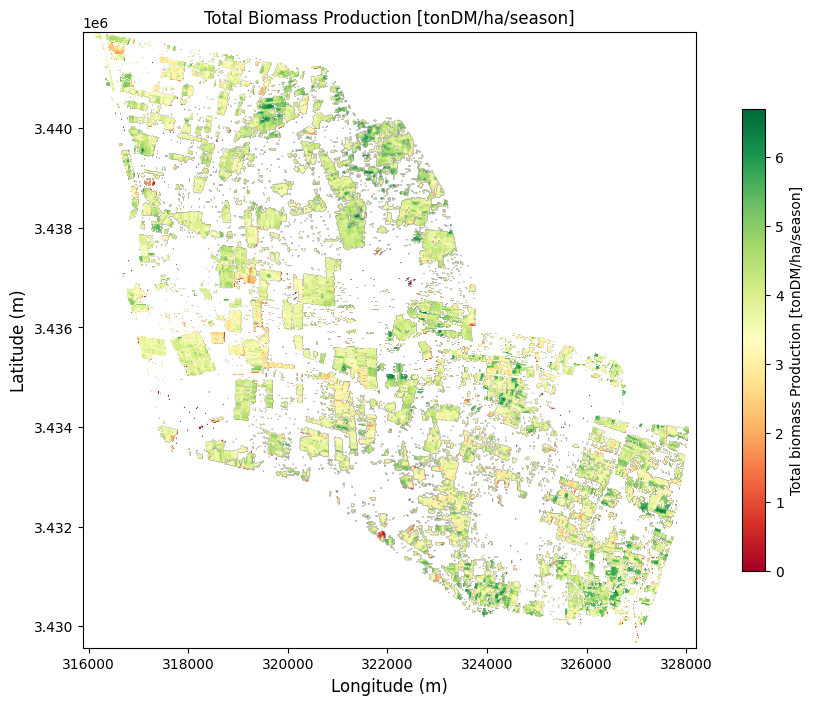

In [13]:
nodata_value = -9999

# Total seasonal biomass production
for in_fhsNPP in NPP_fhs:
    # Open the NPP raster file
    NPP = riox.open_rasterio(in_fhsNPP)

    # Handle nodata values by replacing with np.nan
    NPP = NPP.where(NPP != nodata_value)

    # Calculate Total Biomass Production (TBP)
    TBP = (NPP * 22.222) / 1000  # Convert kg to tons

    # Save TBP into output folder
    output_folder = output_folderTBP
    basename = os.path.basename(in_fhsNPP).replace('NPP', 'TBP')
    out_fh = os.path.join(output_folderTBP, basename)

    TBP.rio.to_raster(out_fh, nodata=nodata_value)

    # Plot the raster map
    seasonal = TBP
    spatial_extent = (seasonal.x.min(), seasonal.x.max(), seasonal.y.min(), seasonal.y.max())

    # Calculate and print the mean and standard deviation
    print('The mean & SD for', basename, '=', np.nanmean(seasonal).round(1), '&', np.nanstd(seasonal).round(1))

    # Plot the raster
    plt.figure(figsize=(12, 8))
    plt.imshow(seasonal[0], cmap='RdYlGn', vmin=np.nanmin(seasonal), vmax=np.nanmax(seasonal), extent=spatial_extent)
    plt.colorbar(shrink=0.75, label='Total biomass Production [tonDM/ha/season]')
    plt.xlabel('Longitude (m)', fontsize=12)
    plt.ylabel('Latitude (m)', fontsize=12)
    plt.title('Total Biomass Production [tonDM/ha/season]')
    plt.clim()
    plt.show()


### **b) Calculate Yield**

Crop parameters

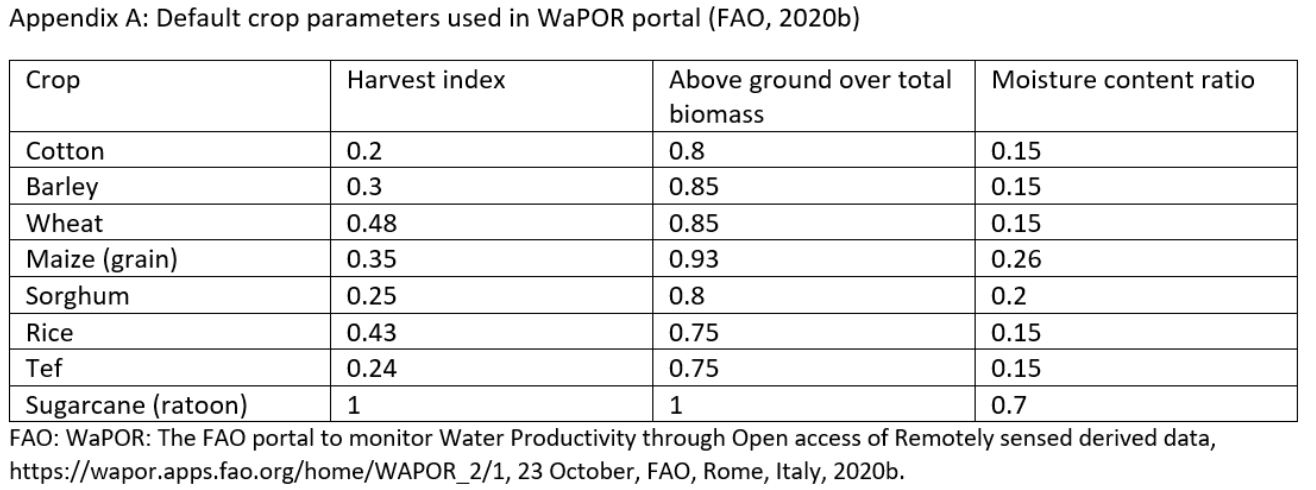

In [14]:
# Update the crop parameters specific to the crop being modeled

MC = 0.15    # Moisture content in the harvested product (fractional). Indicates the amount of water content present in the crop at the time of harvest.
fc = 1       # Light use efficiency correction factor. For C3 plants (like wheat, rice), the value is typically 1, meaning no correction.
AOT = 0.75   # Above (or below) ground over total biomass production ratio (AOT). This ratio indicates that 85% of the total biomass is produced above ground (like stems, leaves, etc.).
HI = 0.43    # Harvest Index (HI), representing the fraction of the above(below) biomass that becomes harvestable yield. A value of 0.48 means 48% of the total biomass contributes to the yield (e.g., grains).


In [15]:
# Check if the TBP is calculated
TBP_fhs = glob.glob(os.path.join(output_folderTBP, '*.tif'))
TBP_fhs

['/content/output/TBP_season/pywapor_TBP_S_2024-05-01_2024-09-30.tif']

The mean & SD for yield: 1.5 & 0.30000001192092896


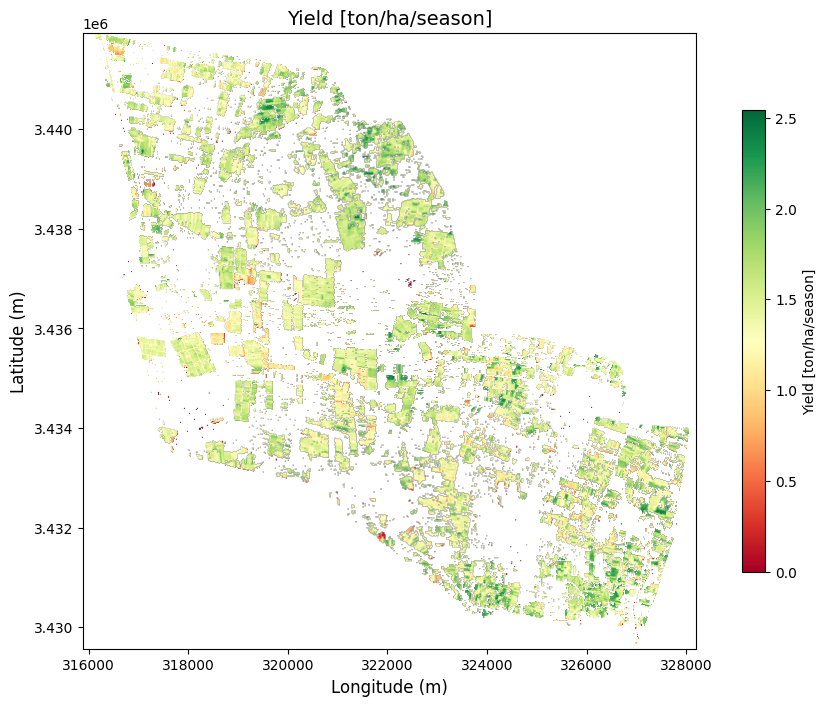

In [16]:
"""
This script computes Harvestable Yield from TBP raster files using crop parameters like HI, AOT, MC, and fc.
The results are saved as raster files, visualized on a color-coded map, and the mean and SD of the yield are calculated and printed.
"""
# Step 1: Load TBP (Total Biomass Production) raster files
TBP_fhs = glob.glob(os.path.join(output_folderTBP, '*.tif'))  # Retrieve all TBP files from the output folder

# Step 2: Loop through each TBP file to compute and save yield
for in_fhsTBP in TBP_fhs:
    TBP = riox.open_rasterio(in_fhsTBP)  # Load the TBP raster file

    # Calculate the Harvestable Yield (Y) using the formula:
    Y = HI * AOT * fc * (TBP / (1 - MC))

    # Step 3: Save the calculated yield (Y) to the output folder
    output_folder = output_folderyield
    basename = os.path.basename(in_fhsTBP).replace('TBP', 'yield')  # Modify the filename for the yield output
    out_fh = os.path.join(output_folderyield, basename)
    Y.rio.to_raster(out_fh)  # Save the yield raster file

    # Step 4: Plot and visualize the Yield data
    seasonal = Y  # Assign the yield data to 'seasonal' for plotting
    spatial_extent = (seasonal.x.min(), seasonal.x.max(), seasonal.y.min(), seasonal.y.max())  # Define the spatial extent

    # Step 5: Calculate and print the mean and standard deviation of the yield
    mean_yield = np.nanmean(seasonal).round(1)
    std_yield = np.nanstd(seasonal).round(1)
    print(f'The mean & SD for yield: {mean_yield} & {std_yield}')

    # Step 6: Plot the Yield raster map with a color bar and labels
    plt.figure(figsize=(12, 8))
    plt.imshow(seasonal[0], cmap='RdYlGn', vmin=np.nanmin(seasonal), vmax=np.nanmax(seasonal), extent=spatial_extent)
    plt.colorbar(shrink=0.75, label='Yield [ton/ha/season]')
    plt.xlabel('Longitude (m)', fontsize=12)  # Label the x-axis
    plt.ylabel('Latitude (m)', fontsize=12)  # Label the y-axis
    plt.title('Yield [ton/ha/season]', fontsize=14)  # Title for the plot
    plt.clim()
    plt.show()

### **c) Calculate Water Productivity**

Calculate **biomass water productivity** (WPb), which is defined as the total biomass production divided by the actual evapotranspiration (AETI):

$$ WPb = \frac{TBP}{AETI} \times 100 $$

To adjust the unit, the multiplication by 100 is required for WPb to be expressed in **kgDM/m³**. This adjustment accounts for TBP being in **tonDM/ha** and AETI in **mm/season**.


/content/output/TBP_season/pywapor_TBP_S_2024-05-01_2024-09-30.tif
the mean & SD for  = 0.36 & 0.04


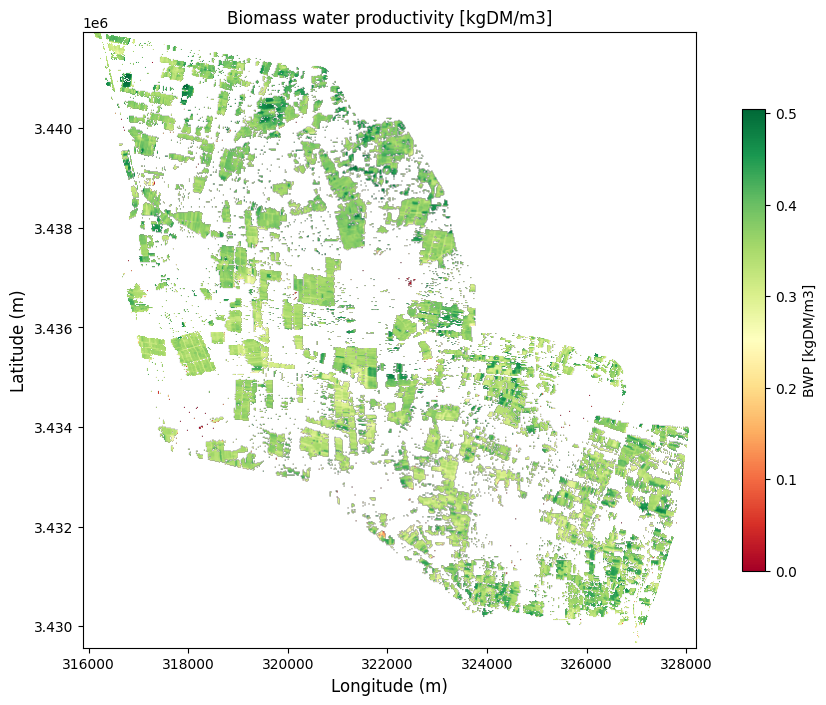

In [17]:
nodata_value = -9999

## Calculate biomass WP
for in_fhET, in_fhTBP in zip(AETI_fhs, TBP_fhs):
    AETI = riox.open_rasterio(in_fhET)
    # Handle nodata values in AETI (replace nodata_value with NaN)
    AETI = AETI.where(AETI != nodata_value)

    TBP = riox.open_rasterio(in_fhTBP)
    WP  = TBP/AETI*100 # the multiplication with 100 is to correct the units to kg/m3 (from AETI in mm/season and TBP in ton/ha)
    print (in_fhTBP)


    # save into output folder
    output_folder = output_folderBWP
    basename = os.path.basename(in_fhET).replace('AETI', 'BWP')
    out_fh = os.path.join(output_folderBWP, basename)
    WP.rio.to_raster(out_fh)

    # Plot the raster map
    seasonal = WP
    spatial_extent = (seasonal.x.min(), seasonal.x.max(), seasonal.y.min(), seasonal.y.max())

    # calculate the mean, SD
    print ('the mean & SD for ', '=', np.nanmean(seasonal).round(2),'&',np.nanstd(seasonal).round(2))

    plt.figure(figsize = (12,8))
    plt.imshow(seasonal[0], cmap='RdYlGn', vmin=np.nanmin(seasonal), vmax=np.nanmax(seasonal), extent=spatial_extent)
    plt.colorbar(shrink=0.75, label='BWP [kgDM/m3]')
    plt.xlabel('Longitude (m)', fontsize=12)  # add axes label
    plt.ylabel('Latitude (m)', fontsize=12)
    plt.title('Biomass water productivity [kgDM/m3]')
    plt.clim()
    plt.show ()

### **d) Calculate crop water productivity**

**The crop water productivity (cWP)**, defined as the ratio of harvestable yield (Y) to actual evapotranspiration (AETI). The formula used is:

$$ cWP = \frac{Y}{AETI} \times 100 $$

The multiplication by 100 adjusts the units to **kg/m³**, as AETI is in **mm/season** and yield is in **ton/ha**.


the mean & SD for  = 0.14 & 0.02


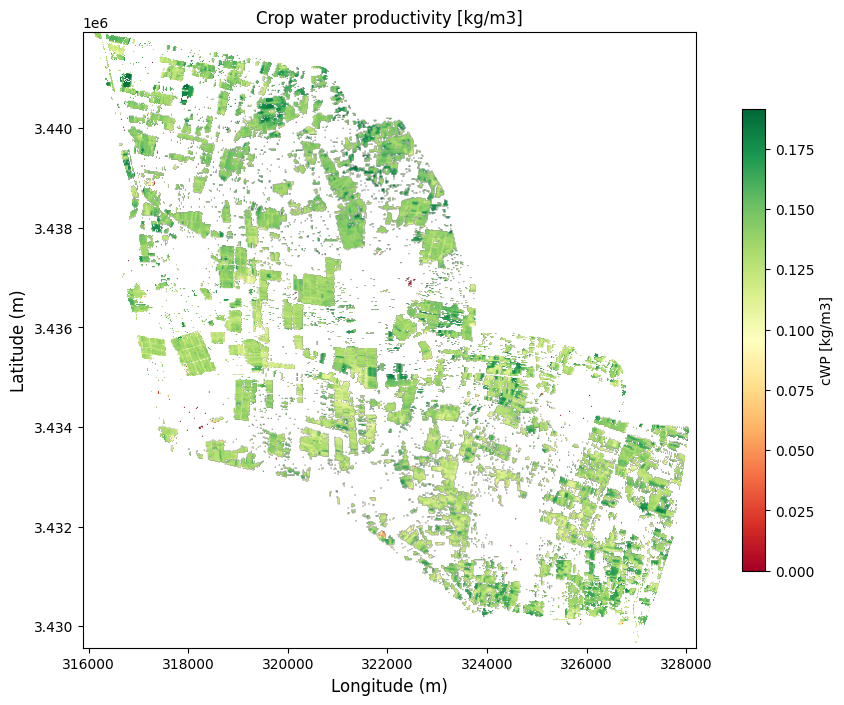

In [18]:
"""
This script calculates crop water productivity (cWP), defined as the ratio of harvestable yield (Y) to actual evapotranspiration (AETI).
The script saves the calculated cWP values as raster files and visualizes them on a map.
Additionally, the mean and standard deviation (SD) of cWP are computed and printed for each raster.
"""
nodata_value = -9999

Y_fhs = glob.glob(os.path.join(output_folderyield, '*.tif'))

## Calculate biomass crop WP
for in_fhET, in_fhY in zip(AETI_fhs, Y_fhs):
    AETI = riox.open_rasterio(in_fhET)
    # Handle nodata values in AETI (replace nodata_value with NaN)
    AETI = AETI.where(AETI != nodata_value)

    Y    = riox.open_rasterio(in_fhY)
    cWP  = Y/AETI*100 # the multiplication with 100 is to correct the units to kg/m3 (from AETI in mm/season and TBP in ton/ha)

    # save into output folder
    output_folder = output_foldercWP
    basename = os.path.basename(in_fhET).replace('AETI', 'cWP')
    out_fh = os.path.join(output_foldercWP, basename)
    cWP.rio.to_raster(out_fh)

    # Plot the raster map
    seasonal = cWP
    spatial_extent = (cWP.x.min(), cWP.x.max(), cWP.y.min(), cWP.y.max())

    # calculate the mean, SD
    print ('the mean & SD for ', '=', np.nanmean(seasonal).round(2),'&',np.nanstd(seasonal).round(2))

    plt.figure(figsize = (12,8))
    plt.imshow(seasonal[0], cmap='RdYlGn', vmin=np.nanmin(seasonal), vmax=np.nanmax(seasonal), extent=spatial_extent)
    plt.colorbar(shrink=0.75, label='cWP [kg/m3]')
    plt.xlabel('Longitude (m)', fontsize=12)  # add axes label
    plt.ylabel('Latitude (m)', fontsize=12)
    plt.title('Crop water productivity [kg/m3]')
    plt.clim()
    plt.show ()

## Download files


In [19]:
# 1) Compress the specified folders into a single zip file
!zip -r /content/Module_3a_Yield_WP.zip /content/output/

# 2) Download the zipped file from Colab to your local machine
from google.colab import files
files.download(r'/content/Module_3a_Yield_WP.zip')


  adding: content/output/ (stored 0%)
  adding: content/output/Cwp_season/ (stored 0%)
  adding: content/output/Cwp_season/pywapor_cWP_S_2024-05-01_2024-09-30.tif (deflated 84%)
  adding: content/output/TBP_season/ (stored 0%)
  adding: content/output/TBP_season/pywapor_TBP_S_2024-05-01_2024-09-30.tif (deflated 84%)
  adding: content/output/yield_season/ (stored 0%)
  adding: content/output/yield_season/pywapor_yield_S_2024-05-01_2024-09-30.tif (deflated 84%)
  adding: content/output/BWP_season/ (stored 0%)
  adding: content/output/BWP_season/pywapor_BWP_S_2024-05-01_2024-09-30.tif (deflated 84%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>